# EDA: Subset Dataset (10k)

This notebook contains exploratory data analysis for the 10k sample subset of chest X-ray metadata.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline

### Load the 10k Subset Data

In [12]:
file_path = '../data/subset_10k_metadata.csv'
df = pd.read_csv(file_path)

print(f"Data Shape: {df.shape}")
df.head()

Data Shape: (10000, 2)


,Image Index,Finding Labels
0,00012819_000.png,No Finding
1,00003789_000.png,Nodule|Pneumonia
2,00003392_003.png,Atelectasis
3,00000652_009.png,Atelectasis|Consolidation|Infiltration
4,00010758_011.png,No Finding


### Basic Metadata Summary

In [13]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Image Index     10000 non-null  object
 1   Finding Labels  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


,Image Index,Finding Labels
count,10000,10000
unique,10000,294
top,00012819_000.png,No Finding
freq,1,5694


### Finding Labels Distribution
The dataset is multi-label, so we'll explode the 'Finding Labels' to see individual class counts.

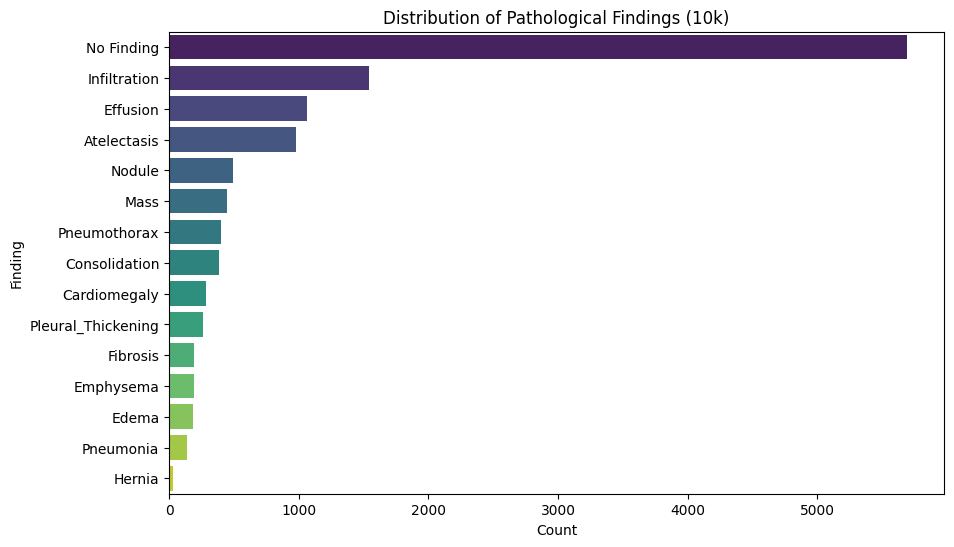

In [14]:
# Extract unique labels and plot
all_labels = df['Finding Labels'].str.split('|').explode().value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=all_labels.values, y=all_labels.index, hue=all_labels.index, palette='viridis', legend=False)
plt.title('Distribution of Pathological Findings (10k)')
plt.xlabel('Count')
plt.ylabel('Finding')
plt.show()

### Frequency of Label Combinations

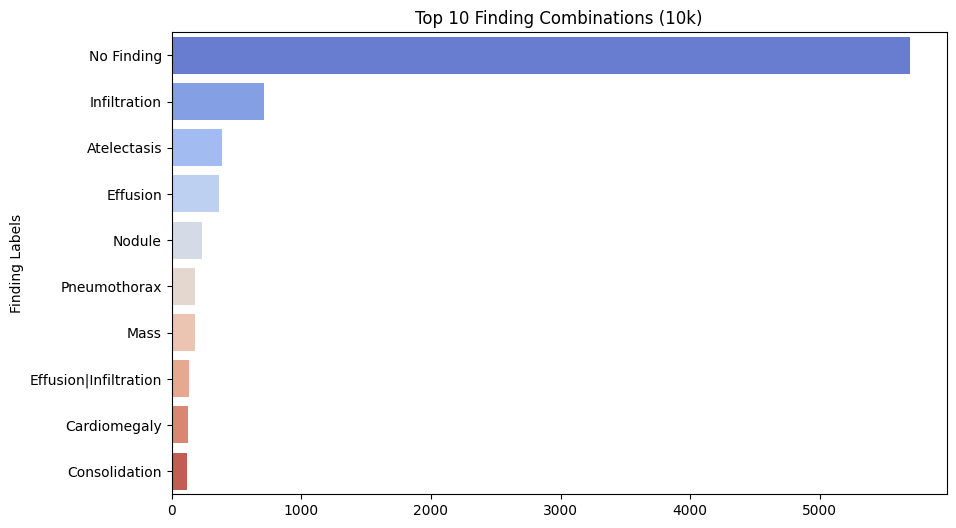

In [15]:
top_combos = df['Finding Labels'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_combos.values, y=top_combos.index, hue=top_combos.index, palette='coolwarm', legend=False)
plt.title('Top 10 Finding Combinations (10k)')
plt.show()

### Co-occurrence Matrices

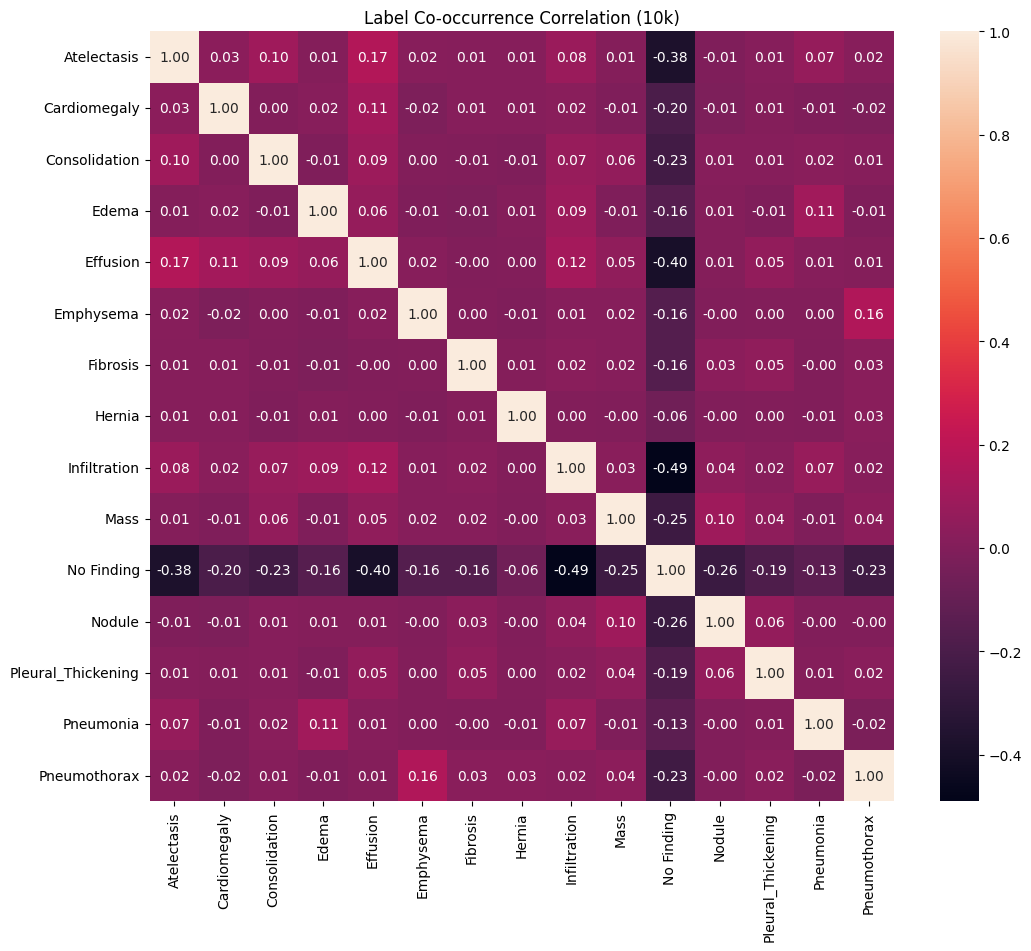

In [16]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
encoded = mlb.fit_transform(df['Finding Labels'].str.split('|'))
encoded_df = pd.DataFrame(encoded, columns=mlb.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(encoded_df.corr(), annot=True, cmap='rocket', fmt=".2f")
plt.title('Label Co-occurrence Correlation (10k)')
plt.show()